In [56]:
library(tidyverse)
library(stringr)
library(readr)
library(fs)
library(ggplot2)
library(dplyr)
library(broom)
library(tidyr)

ERROR: Error in library(kable): there is no package called ‘kable’


In [2]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, kableExtra, modelsummary)

f <- function(x) {
  r <- quantile(x, probs = c(0.10, 0.25, 0.5, 0.75, 0.90))
  names(r) <- c("ymin","lower","middle","upper","ymax")
  r
}

Loading required package: pacman

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

Warning message in utils::install.packages(package, ...):
“installation of package ‘kableExtra’ had non-zero exit status”

kableExtra installed

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘datawizard’, ‘insight’, ‘parameters’, ‘performance’, ‘tables’


Warning message in utils::install.packages(package, ...):
“installation of package ‘insight’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘tables’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘datawizard’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘bayestestR’ had non-zero exit status”
Warning message in u

In [4]:
install.packages("kableExtra", verbose = TRUE)

Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)

system (cmd0): /local/5261/econ470001/conda-env-py313/lib/R/bin/R CMD INSTALL

foundpkgs: kableExtra, /tmp/RtmpltzUvo/downloaded_packages/kableExtra_1.4.0.tar.gz

files: /tmp/RtmpltzUvo/downloaded_packages/kableExtra_1.4.0.tar.gz

Warning message in install.packages("kableExtra", verbose = TRUE):
“installation of package ‘kableExtra’ had non-zero exit status”


In [5]:
data.2010 <- read_csv("..//data/data-2010.csv")
data.2011 <- read_csv("..//data/data-2011.csv")
data.2012 <- read_csv("..//data/data-2012.csv")
data.2013 <- read_csv("..//data/data-2013.csv")
data.2014 <- read_csv("..//data/data-2014.csv")
data.2015 <- read_csv("..//data/data-2015.csv")

Rows: 108222 Columns: 91
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (66): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl (10): partcd_score, risk_star5, risk_star45, risk_star4, risk_star35, ri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68003 Columns: 95
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (71): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...
lgl  (9): risk_star5, risk_star45, risk_star4, risk_star35, risk_star3, risk...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types =

In [6]:
fix_type <- function(df) {
  df$org_parent <- as.character(df$org_parent)
  df
}

data.2011 <- fix_type(data.2011)

In [7]:
combined <- bind_rows(
  data.2010,
  data.2011,
  data.2012,
  data.2013,
  data.2014,
  data.2015
) %>%
  mutate(mkt_share = avg_enrollment / avg_enrolled)

In [8]:
colnames(combined)

[1] "contractid"          "planid"              "fips"               
  [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
  [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
 [10] "last_enrollment"     "state"               "county"             
 [13] "org_type"            "plan_type"           "partd"              
 [16] "snp"                 "eghp"                "org_name"           
 [19] "org_marketing_name"  "plan_name"           "parent_org"         
 [22] "contract_date"       "state_long"          "county_long"        
 [25] "n_elig"              "n_enrol"             "avg_eligibles"      
 [28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
 [31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
 [34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
 [37] "first_enrolled"      "last_enrolled"       "ssa"                
 [40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
 [43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
 [46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
 [49] "mental_health"       "osteo_test"          "physical_monitor"   
 [52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
 [55] "bloodpressure"       "ra_manage"           "copd_test"          
 [58] "bladder"             "falling"             "nodelays"           
 [61] "doctor_communicate"  "carequickly"         "customer_service"   
 [64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
 [67] "appeals_timely"      "appeals_review"      "leave_plan"         
 [70] "audit_problems"      "hold_times"          "info_accuracy"      
 [73] "ttyt_available"      "new_contract"        "partc_score"        
 [76] "partcd_score"        "Star_Rating"         "aged_parta"         
 [79] "aged_partb"          "risk_ab"             "risk_star5"         
 [82] "risk_star45"         "risk_star4"          "risk_star35"        
 [85] "risk_star3"          "risk_star25"         "risk_bonus5"        
 [88] "risk_bonus35"        "risk_bonus0"         "year"               
 [91] "ma_rate"             "org_parent"          "cv_cholscreen"      
 [94] "diab_cholscreen"     "bmi_assess"          "specialneeds_manage"
 [97] "older_medication"    "older_function"      "older_pain"         
[100] "diabetes_eye"        "diabetes_kidney"     "diabetes_bloodsugar"
[103] "diabetes_chol"       "readmissions"        "coordination"       
[106] "improve"             "X39"                 "X40"                
[109] "low_score"           "X41"                 "X42"                
[112] "access_problems"     "mkt_share"

# Problem 1

In [9]:
summary_table <- combined %>%
  group_by(year) %>%
  summarise(
    `Mean Star Rating` = round(mean(Star_Rating, na.rm = TRUE), 2),
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_table)

# A tibble: 6 × 5
   year `Mean Star Rating` `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>              <dbl>               <dbl>         <int>
1  2010               2.97               256.              0.0658        108222
2  2011               3.26               343.              0.0855         68003
3  2012               3.36               377.              0.0856         67246
4  2013               3.55               396.              0.0815         67835
5  2014               3.81               437.              0.08           62344
6  2015               3.96               470.              0.0787         65499


# Problem 2

In [10]:
summary_no_rating <- combined %>%
  filter(is.na(Star_Rating)) %>%
  group_by(year) %>%
  summarise(
    `Mean Enrollments` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(mkt_share, na.rm = TRUE), 4),
    `Total Plans` = n()
  )

print(summary_no_rating)

# A tibble: 6 × 4
   year `Mean Enrollments` `Mean Market Share` `Total Plans`
  <dbl>              <dbl>               <dbl>         <int>
1  2010               107.              0.0673         48643
2  2011               168.              0.09           12754
3  2012               173.              0.0567          9077
4  2013               214.              0.06            3661
5  2014               258.              0.0557          3708
6  2015               314.              0.0405          4680


# Problem 3

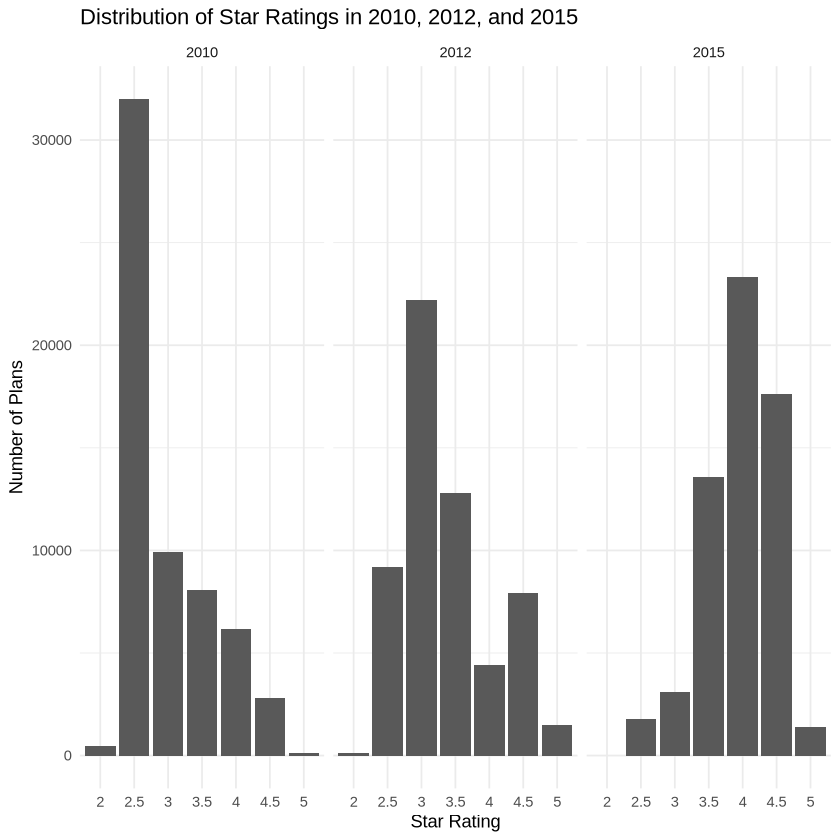

In [11]:
combined %>%
  filter(year %in% c(2010, 2012, 2015), !is.na(Star_Rating)) %>%
  mutate(year = as.factor(year)) %>%
  ggplot(aes(x = as.factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~ year) +
  labs(
    title = "Distribution of Star Ratings in 2010, 2012, and 2015",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal()

# Problem 4

In [12]:
combined <- combined %>%
  mutate(
    star_3   = as.integer(partc_score == 3),
    star_35  = as.integer(partc_score== 3.5),
    star_4   = as.integer(partc_score == 4),
    star_45  = as.integer(partc_score >= 4.5)
  )

results_list <- list()

for(yr in 2010:2015){
  cat("\nYear:", yr, "\n")
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(partc_score), !is.na(mkt_share)))
  print(summary(ols))
}



Year: 2010 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr, !is.na(partc_score), 
        !is.na(mkt_share)))

Residuals:
     Min       1Q   Median       3Q      Max 
-0.07593 -0.05415 -0.03449  0.01530  0.72831 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0633531  0.0009855  64.288  < 2e-16 ***
star_3       0.0126028  0.0018242   6.908 5.05e-12 ***
star_35      0.0005280  0.0018955   0.279  0.78059    
star_4      -0.0036213  0.0021302  -1.700  0.08916 .  
star_45     -0.0075592  0.0026960  -2.804  0.00505 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.09138 on 18988 degrees of freedom
Multiple R-squared:  0.003954,	Adjusted R-squared:  0.003744 
F-statistic: 18.84 on 4 and 18988 DF,  p-value: 1.788e-15


Year: 2011 

Call:
lm(formula = mkt_share ~ star_3 + star_35 + star_4 + star_45, 
    data = combined %>% filter(year == yr,

In [13]:
results_list <- list()

for(yr in 2010:2015){
  ols <- lm(mkt_share ~ star_3 + star_35 + star_4 + star_45, 
            data = combined %>% filter(year == yr, !is.na(partc_score), !is.na(mkt_share)))
  results_list[[as.character(yr)]] <- coef(ols)
}

ols_table <- as.data.frame(results_list)
colnames(ols_table) <- c("2010", "2011", "2012", "2013", "2014", "2015")
rownames(ols_table) <- c("Intercept (≤2.5 stars)", "3 Stars", "3.5 Stars", "4 Stars", "4.5+ Stars")

print(round(ols_table, 4))

                          2010    2011    2012   2013   2014    2015
Intercept (≤2.5 stars)  0.0634  0.0813  0.0876 0.0488 0.0606  0.0764
3 Stars                 0.0126  0.0009  0.0202 0.0653 0.0450  0.0104
3.5 Stars               0.0005  0.0348  0.0072 0.0322 0.0221  0.0167
4 Stars                -0.0036 -0.0116 -0.0250 0.0264 0.0219 -0.0048
4.5+ Stars             -0.0076 -0.0221 -0.0196 0.0105 0.0026  0.0071


# Problem 5

filter first

In [14]:
ma.2010 <- data.2010 %>%
  filter(!is.na(breastcancer_screen), !is.na(rectalcancer_screen),
         !is.na(cv_diab_cholscreen), !is.na(glaucoma_test), !is.na(monitoring),
         !is.na(flu_vaccine), !is.na(pn_vaccine), !is.na(physical_health),
         !is.na(mental_health), !is.na(osteo_test), !is.na(physical_monitor),
         !is.na(primaryaccess), !is.na(osteo_manage), !is.na(diab_healthy),
         !is.na(bloodpressure), !is.na(ra_manage), !is.na(copd_test), !is.na(bladder),
         !is.na(falling), !is.na(nodelays), !is.na(doctor_communicate),
         !is.na(carequickly), !is.na(customer_service),
         !is.na(overallrating_care), !is.na(overallrating_plan),
         !is.na(complaints_plan), !is.na(appeals_timely), !is.na(appeals_review),
         !is.na(leave_plan), !is.na(audit_problems), !is.na(hold_times),
         !is.na(info_accuracy), !is.na(ttyt_available)) %>%
  mutate(
    raw_rating = rowMeans(cbind(breastcancer_screen, rectalcancer_screen,
                                cv_diab_cholscreen, glaucoma_test, monitoring,
                                flu_vaccine, pn_vaccine, physical_health,
                                mental_health, osteo_test, physical_monitor,
                                primaryaccess, osteo_manage, diab_healthy,
                                bloodpressure, ra_manage, copd_test, bladder,
                                falling, nodelays, doctor_communicate,
                                carequickly, customer_service,
                                overallrating_care, overallrating_plan,
                                complaints_plan, appeals_timely, appeals_review,
                                leave_plan, audit_problems, hold_times,
                                info_accuracy, ttyt_available))
  )

# Check thresholds
ma.2010 %>%
  select(raw_rating, partc_score) %>%
  filter(!is.na(partc_score)) %>%
  group_by(partc_score) %>%
  summarise(
    min_raw = min(raw_rating, na.rm = TRUE),
    max_raw = max(raw_rating, na.rm = TRUE)
  )

partc_score,min_raw,max_raw
<dbl>,<dbl>,<dbl>
2.5,2.303030,2.727273
3.0,2.757576,3.242424
3.5,3.303030,3.636364
4.0,3.606061,3.848485
4.5,3.969697,4.090909


In [15]:
round_up_table <- ma.2010 %>%
  filter(!is.na(partc_score)) %>%
  mutate(
    round_up = case_when(
      raw_rating >= 2.75 & partc_score == 3.0  ~ "Rounded up to 3",
      raw_rating >= 3.25 & partc_score == 3.5  ~ "Rounded up to 3.5",
      raw_rating >= 3.75 & partc_score == 4.0  ~ "Rounded up to 4",
      raw_rating >= 4.25 & partc_score == 4.5  ~ "Rounded up to 4.5",
      raw_rating >= 4.75 & partc_score == 5.0  ~ "Rounded up to 5",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(round_up)) %>%
  count(round_up) %>%
  rename(`Star Rating` = round_up, `Number of Plans` = n)

print(round_up_table)

# A tibble: 3 × 2
  `Star Rating`     `Number of Plans`
  <chr>                         <int>
1 Rounded up to 3                2217
2 Rounded up to 3.5              1462
3 Rounded up to 4                 698


build raw rating then filter

In [16]:
quality_vars <- c(
  "breastcancer_screen",
  "rectalcancer_screen",
  "cv_diab_cholscreen",
  "glaucoma_test",
  "monitoring",
  "flu_vaccine",
  "pn_vaccine",
  "physical_health",
  "mental_health",
  "osteo_test",
  "physical_monitor",
  "primaryaccess",
  "osteo_manage",
  "diab_healthy",
  "bloodpressure",
  "ra_manage",
  "copd_test",
  "bladder",
  "falling",
  "nodelays",
  "doctor_communicate",
  "carequickly",
  "customer_service",
  "overallrating_care",
  "overallrating_plan",
  "complaints_plan",
  "appeals_timely",
  "appeals_review",
  "leave_plan",
  "audit_problems",
  "hold_times",
  "info_accuracy",
  "ttyt_available"
)

datanew.2010 <- data.2010 %>%
  mutate(
    mkt_share = avg_enrollment / avg_enrolled)  %>%
    rowwise() %>%
  mutate(
    raw_rating = mean(c_across(all_of(quality_vars)), na.rm = TRUE)
  ) %>%
  ungroup()

In [17]:
colnames(datanew.2010)

[1] "contractid"          "planid"              "fips"               
 [4] "n_nonmiss"           "avg_enrollment"      "sd_enrollment"      
 [7] "min_enrollment"      "max_enrollment"      "first_enrollment"   
[10] "last_enrollment"     "state"               "county"             
[13] "org_type"            "plan_type"           "partd"              
[16] "snp"                 "eghp"                "org_name"           
[19] "org_marketing_name"  "plan_name"           "parent_org"         
[22] "contract_date"       "state_long"          "county_long"        
[25] "n_elig"              "n_enrol"             "avg_eligibles"      
[28] "sd_eligibles"        "min_eligibles"       "max_eligibles"      
[31] "first_eligibles"     "last_eligibles"      "avg_enrolled"       
[34] "sd_enrolled"         "min_enrolled"        "max_enrolled"       
[37] "first_enrolled"      "last_enrolled"       "ssa"                
[40] "ncount"              "breastcancer_screen" "rectalcancer_screen"
[43] "cv_diab_cholscreen"  "glaucoma_test"       "monitoring"         
[46] "flu_vaccine"         "pn_vaccine"          "physical_health"    
[49] "mental_health"       "osteo_test"          "physical_monitor"   
[52] "primaryaccess"       "osteo_manage"        "diab_healthy"       
[55] "bloodpressure"       "ra_manage"           "copd_test"          
[58] "bladder"             "falling"             "nodelays"           
[61] "doctor_communicate"  "carequickly"         "customer_service"   
[64] "overallrating_care"  "overallrating_plan"  "complaints_plan"    
[67] "appeals_timely"      "appeals_review"      "leave_plan"         
[70] "audit_problems"      "hold_times"          "info_accuracy"      
[73] "ttyt_available"      "new_contract"        "partc_score"        
[76] "partcd_score"        "Star_Rating"         "aged_parta"         
[79] "aged_partb"          "risk_ab"             "risk_star5"         
[82] "risk_star45"         "risk_star4"          "risk_star35"        
[85] "risk_star3"          "risk_star25"         "risk_bonus5"        
[88] "risk_bonus35"        "risk_bonus0"         "year"               
[91] "ma_rate"             "mkt_share"           "raw_rating"

In [18]:
round_up_counts <- datanew.2010 %>%
  filter(!is.na(raw_rating)) %>%
  filter(!is.na(partc_score)) %>%
  mutate(
    round_ups = case_when(
      raw_rating >= 2.75 & partc_score == 3.0  ~ "Rounded up to 3",
      raw_rating >= 3.25 & partc_score == 3.5  ~ "Rounded up to 3.5",
      raw_rating >= 3.75 & partc_score == 4.0  ~ "Rounded up to 4",
      raw_rating >= 4.25 & partc_score == 4.5  ~ "Rounded up to 4.5",
      raw_rating >= 4.75 & partc_score == 5.0  ~ "Rounded up to 5",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(round_ups)) %>%
  count(round_ups) %>%
  rename('Star Rating' = round_ups, 'Corresponding Number Of Plans' = n)

print(round_up_counts)

# A tibble: 5 × 2
  `Star Rating`     `Corresponding Number Of Plans`
  <chr>                                       <int>
1 Rounded up to 3                              9918
2 Rounded up to 3.5                            8091
3 Rounded up to 4                              4284
4 Rounded up to 4.5                             771
5 Rounded up to 5                                30


# Problem 6

In [19]:
install.packages("rdrobust")
library(rdrobust)


Installing package into ‘/home/ski2983/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [20]:
rd1 <- datanew.2010 %>%
  filter(!is.na(raw_rating), !is.na(mkt_share)) %>%
  mutate(score = raw_rating - 2.75)   # center running variable at cutoff

est1 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.125, p = 1, kernel = "uniform", vce = "hc0")
summary(est1)

Sharp RD estimates using local polynomial regression.

Number of Obs.                26038
BW type                      Manual
Kernel                      Uniform
VCE method                      HC0

Number of Obs.                12800        13238
Eff. Number of Obs.            5094          858
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                   0.125        0.125
BW bias (b)                   0.125        0.125
rho (h/b)                     1.000        1.000
Unique Obs.                   12800        13238

                   Point    Robust Inference
                Estimate         z     P>|z|      [ 95% C.I. ]       
---------------------------------------------------------------------
     RD Effect     0.046    -0.802     0.422    [-0.033 , 0.014]     


In [21]:
rd2 <- datanew.2010 %>%
  filter(!is.na(raw_rating), !is.na(mkt_share)) %>%
  mutate(score = raw_rating - 3.25)   # center running variable at cutoff

est2 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.125, p = 1, kernel = "uniform", vce = "hc0")
summary(est2)


Sharp RD estimates using local polynomial regression.

Number of Obs.                26038
BW type                      Manual
Kernel                      Uniform
VCE method                      HC0

Number of Obs.                18122         7916
Eff. Number of Obs.            1164         1003
Order est. (p)                    1            1
Order bias  (q)                   2            2
BW est. (h)                   0.125        0.125
BW bias (b)                   0.125        0.125
rho (h/b)                     1.000        1.000
Unique Obs.                   18122         7916

                   Point    Robust Inference
                Estimate         z     P>|z|      [ 95% C.I. ]       
---------------------------------------------------------------------
     RD Effect    -0.049    -5.202     0.000    [-0.089 , -0.040]    


In [22]:
tibble(
  Cutoff   = c("3 Stars vs. 2.5 Stars", "3.5 Stars vs. 3 Stars"),
  Estimate = round(c(est1$coef[1], est2$coef[1]), 4)
) %>% print()

# A tibble: 2 × 2
  Cutoff                Estimate
  <chr>                    <dbl>
1 3 Stars vs. 2.5 Stars   0.0461
2 3.5 Stars vs. 3 Stars  -0.049 


# Problem 7

# A tibble: 5 × 2
  Bandwidth Estimate
      <dbl>    <dbl>
1      0.1    0.0478
2      0.12   0.0445
3      0.13   0.0482
4      0.14   0.0458
5      0.15   0.0438


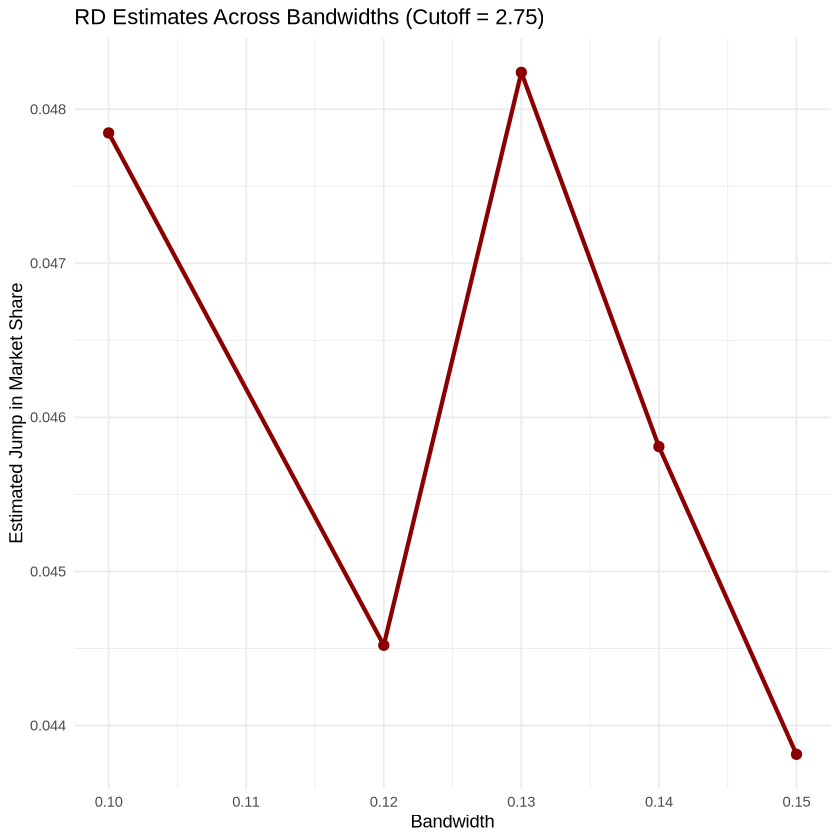

In [34]:
est0.1 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.1, p = 1, kernel = "uniform", vce = "hc0")
est0.12 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.12, p = 1, kernel = "uniform", vce = "hc0")
est0.13 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.13, p = 1, kernel = "uniform", vce = "hc0")
est0.14 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.14, p = 1, kernel = "uniform", vce = "hc0")
est0.15 <- rdrobust(y = rd1$mkt_share, x = rd1$score, c = 0,
                 h = 0.15, p = 1, kernel = "uniform", vce = "hc0")

results_table_275 <- tibble(
  Bandwidth = c(0.10, 0.12, 0.13, 0.14, 0.15),
  Estimate = c(
    est0.1$coef[1],   # h = 0.10
    est0.12$coef[1],  # h = 0.12
    est0.13$coef[1],  # h = 0.13
    est0.14$coef[1],  # h = 0.14
    est0.15$coef[1]   # h = 0.15
  )
)

print(results_table_275)

ggplot(results_table_275, aes(x = Bandwidth, y = Estimate)) +
  geom_line(size = 1.2, color = "darkred") +
  geom_point(size = 2.5, color = "darkred") +
  labs(
    title = "RD Estimates Across Bandwidths (Cutoff = 2.75)",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share"
  ) +
  theme_minimal()


# A tibble: 5 × 2
  Bandwidth Estimate
      <dbl>    <dbl>
1      0.1   -0.0651
2      0.12  -0.0458
3      0.13  -0.0493
4      0.14  -0.0540
5      0.15  -0.0232


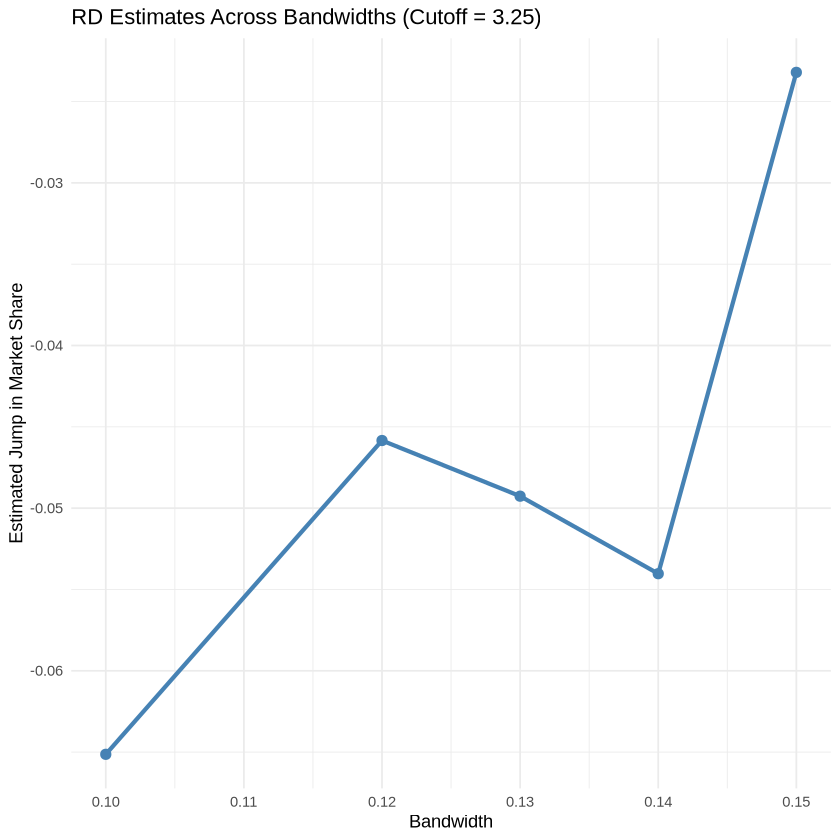

In [31]:
est3 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.1, p = 1, kernel = "uniform", vce = "hc0")

est4 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.12, p = 1, kernel = "uniform", vce = "hc0")

est5 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.13, p = 1, kernel = "uniform", vce = "hc0")

est6 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.14, p = 1, kernel = "uniform", vce = "hc0")

est7 <- rdrobust(y = rd2$mkt_share, x = rd2$score, c = 0,
                 h = 0.15, p = 1, kernel = "uniform", vce = "hc0")

results_table_325 <- tibble(
  Bandwidth = c(0.10, 0.12, 0.13, 0.14, 0.15),
  Estimate = c(
    est3$coef[1],   # h = 0.10
    est4$coef[1],   # h = 0.12
    est5$coef[1],   # h = 0.13
    est6$coef[1],    # h = 0.14
    est7$coef[1]    # h = 0.15
  )
)

print(results_table_325)

ggplot(results_table_325, aes(x = Bandwidth, y = Estimate)) +
  geom_line(size = 1.2, color = "steelblue") +
  geom_point(size = 2.5, color = "steelblue") +
  labs(
    title = "RD Estimates Across Bandwidths (Cutoff = 3.25)",
    x = "Bandwidth",
    y = "Estimated Jump in Market Share"
  ) +
  theme_minimal()



# Problem 8

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15955 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 15955 rows containing missing values (`geom_point()`).”


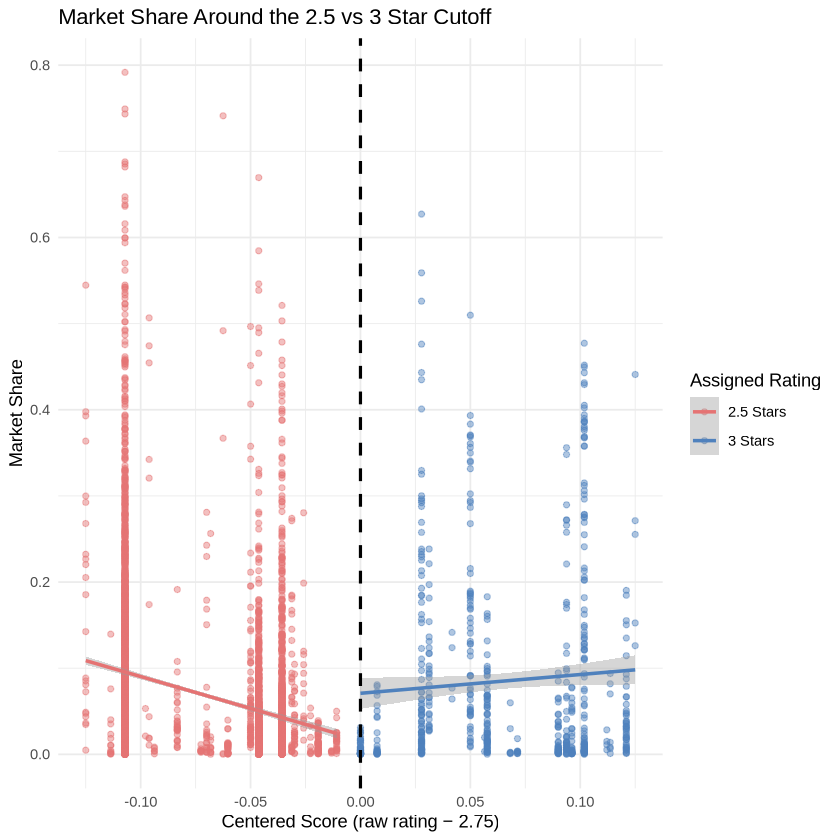

In [42]:
plans_3 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(2.5, 3)
  )

band_3 <- plans_3 %>%
  filter(
    raw_rating >= 2.5,
    raw_rating <= 3,
    (raw_rating < 2.75  & Star_Rating == 2.5) |
    (raw_rating >= 2.75 & Star_Rating == 3)
  )

rd_3 <- band_3 %>%
  mutate(
    score = raw_rating - 2.75,          
    treat_group = score >= 0,           
    in_window = between(score, -0.125, 0.125),
    interaction = score * treat_group
  )

p_3 <- ggplot(rd_3 %>% filter(in_window),
             aes(x = score, y = mkt_share, color = treat_group)) +
  geom_point(alpha = 0.45, size = 1.4) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(
    values = c("FALSE" = "#E57373", "TRUE" = "#4F81BD"),
    labels = c("2.5 Stars", "3 Stars")
  ) +
  labs(
    title = "Market Share Around the 2.5 vs 3 Star Cutoff",
    x = "Centered Score (raw rating − 2.75)",
    y = "Market Share",
    color = "Assigned Rating"
  ) +
  theme_minimal()

p_3


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3641 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 3641 rows containing missing values (`geom_point()`).”


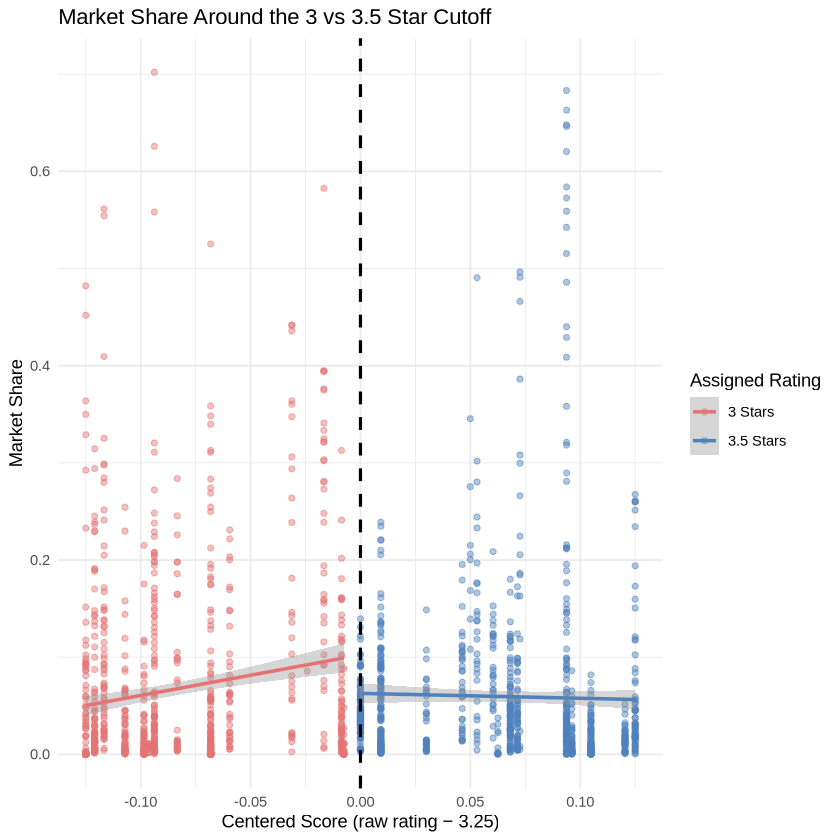

In [43]:
plans_3.5 <- datanew.2010 %>%
  filter(
    !is.na(raw_rating),
    !is.na(partc_score),
    Star_Rating %in% c(3, 3.5)
  )

band_3.5 <- plans_3.5 %>%
  filter(
    raw_rating >= 3,
    raw_rating <= 3.5,
    (raw_rating < 3.25  & Star_Rating == 3) |
    (raw_rating >= 3.25 & Star_Rating == 3.5)
  )

rd_3.5 <- band_3.5 %>%
  mutate(
    score = raw_rating - 3.25,          
    treat_group = score >= 0,      
    in_window = between(score, -0.125, 0.125),
    interaction = score * treat_group
  )

p_3.5 <- ggplot(rd_3.5 %>% filter(in_window), 
             aes(x = score, y = mkt_share, color = treat_group)) +
  geom_point(alpha = 0.45, size = 1.4) +
  geom_smooth(method = "lm", se = TRUE) +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 0.9) +
  scale_color_manual(
    values = c("FALSE" = "#E57373", "TRUE" = "#4F81BD"),
    labels = c("3 Stars", "3.5 Stars")
  ) +
  labs(
    title = "Market Share Around the 3 vs 3.5 Star Cutoff",
    x = "Centered Score (raw rating − 3.25)",
    y = "Market Share",
    color = "Assigned Rating"
  ) +
  theme_minimal()

p_3.5


# Problem 9

In [57]:
near_275 <- datanew.2010 %>%
  mutate(
    score = raw_rating - 2.75,
    group = ifelse(score >= 0, "Above cutoff", "Below cutoff")
  ) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes"
  ) %>%
  group_by(group) %>%
  summarise(
    share_HMO = mean(HMO),
    share_PartD = mean(PartD),
    n = n()
  )

cat("Table: Plan Characteristics Around the 2.75 Cutoff\n")
near_275


Table: Plan Characteristics Around the 2.75 Cutoff


group,share_HMO,share_PartD,n
<chr>,<dbl>,<dbl>,<int>
Above cutoff,0.44659810,0.8401899,2528
Below cutoff,0.01943266,0.5491177,22385


In [58]:
near_325 <- datanew.2010 %>%
  mutate(
    score = raw_rating - 3.25,
    group = ifelse(score >= 0, "Above cutoff", "Below cutoff")) %>%
  filter(score >= -0.125, score <= 0.125) %>%
  mutate(
    HMO = str_detect(plan_type, "HMO"),
    PartD = partd == "Yes") %>%
 
group_by(group) %>%
  summarise(
    share_HMO = mean(HMO),
    share_PartD = mean(PartD),
    n = n()
  )

cat("Table: Plan Characteristics Around the 3.25 Cutoff (3–3.5 Stars)\n")
near_325


Table: Plan Characteristics Around the 3.25 Cutoff (3–3.5 Stars)


group,share_HMO,share_PartD,n
<chr>,<dbl>,<dbl>,<int>
Above cutoff,0.3768352,0.8172920,2452
Below cutoff,0.6056941,0.8641975,3969


These tables show you whether plans just above each cutoff look similar to plans just below it. Plans just above the 2.75 threshold are completely different types of plans as the ones above are much more likely to be HMOs and to offer Part D. Plans for just above the 3.25 thresold are slightly different but to a lesser degree. 

# Problem 10 

Overall, a higher star rating shows more enrollment but the comparison is compromised as plans above and below the threshold are different. Raw ratings tend to be more distributed around the thresholds (2.75 and 3.25), and the adjusted ratings create jumps in star assignments. Because plan characteristics are distinct and not comparable right above or below the cutoff, the RD model cannot cleanly isolate the effect of the star rating alone. 